# Core Fiscal Visualizations: Alberta 2026-2029

Cross-cutting summary charts that synthesize the revenue decline, expense growth, deficit trajectory, and mounting debt into clear visual narratives.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# Style setup
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

# Professional palette
DARK_BLUE = '#1B3A5C'
TEAL = '#2A9D8F'
CORAL = '#E76F51'
AMBER = '#E9C46A'
SLATE = '#6B7B8D'

PLOTS_DIR = Path('plots')
PLOTS_DIR.mkdir(exist_ok=True)

# Load data
summary = pd.read_csv('revenue_vs_expense_summary.csv')
revenue = pd.read_csv('revenue_comparison.csv')
expense = pd.read_csv('expense_comparison.csv')
fiscal_summary = pd.read_csv('../Data/fiscal_plan_2026_fiscal_summary.csv')
fin_position = pd.read_csv('../Data/fiscal_plan_2026_financial_position.csv')

years = summary['Fiscal_Year'].tolist()
print('Data loaded successfully.')
print(f'Fiscal years: {years}')
print(f'Summary columns: {summary.columns.tolist()}')

Data loaded successfully.
Fiscal years: ['2024-25', '2025-26', '2026-27', '2027-28', '2028-29']
Summary columns: ['Fiscal_Year', 'Total_Revenue', 'Total_Expense', 'Surplus_Deficit', 'Revenue_Change_Pct', 'Expense_Change_Pct']


## Fiscal Balance Trajectory

A waterfall chart showing how Alberta's $8.3B surplus erodes into deepening deficits, with revenue declines and expense increases as contributing factors.

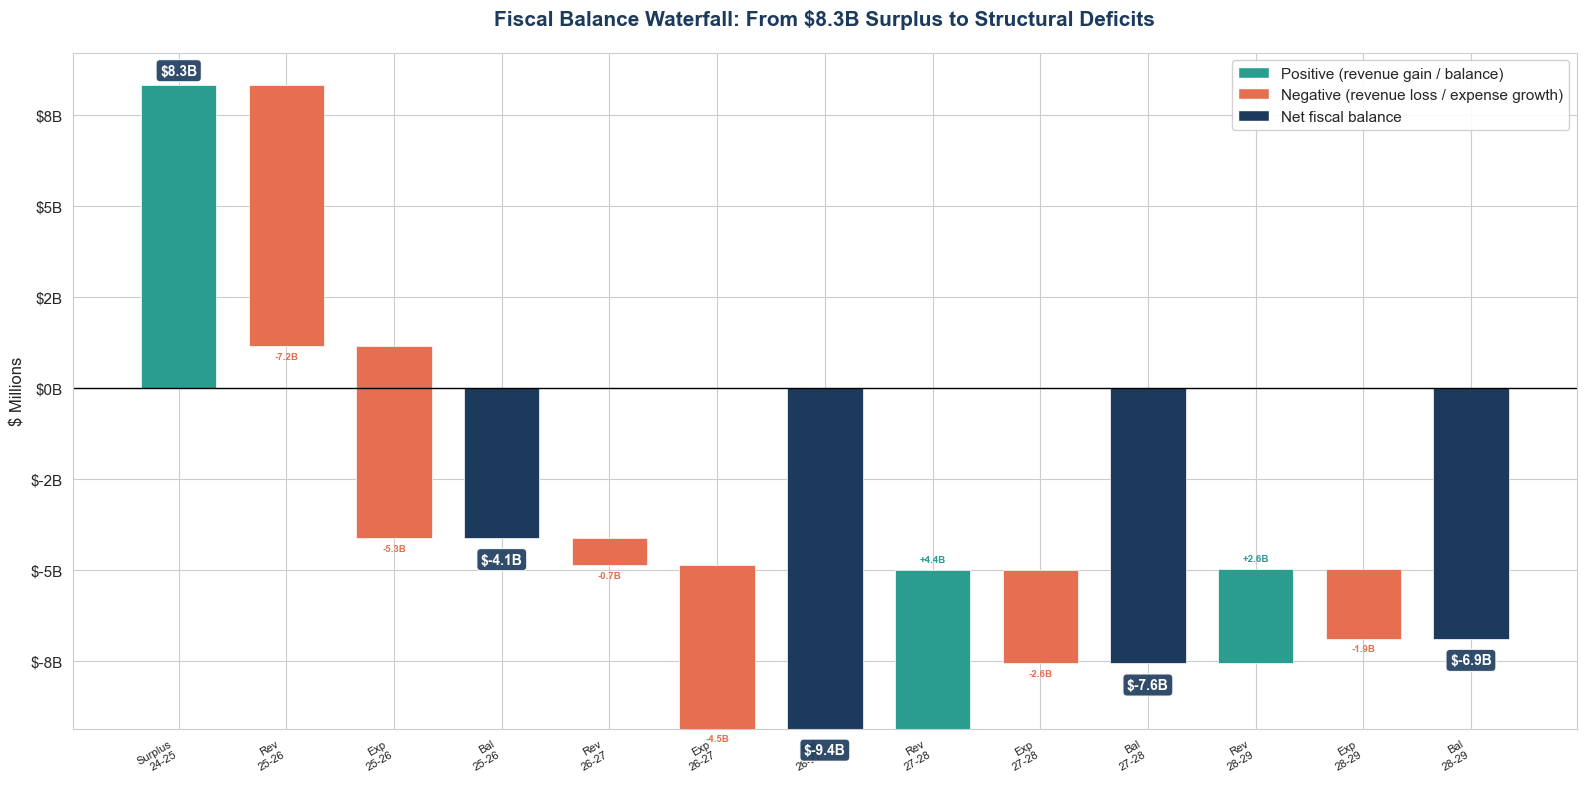

Saved: plots/fiscal_balance_waterfall.png


In [2]:
# Waterfall chart: surplus to deficit trajectory
fig, ax = plt.subplots(figsize=(16, 8))

# Build waterfall data
# Start with 2024-25 surplus, then show revenue change and expense change for each subsequent year
rev = summary['Total_Revenue'].values
exp = summary['Total_Expense'].values
bal = summary['Surplus_Deficit'].values

labels = []
values = []
colors = []
is_total = []

# Starting surplus
labels.append(f'Surplus\n{years[0][-5:]}')
values.append(bal[0])
colors.append(TEAL)
is_total.append(True)

for i in range(1, len(years)):
    rev_change = rev[i] - rev[i-1]
    exp_change = -(exp[i] - exp[i-1])  # negative because expense increase hurts balance
    
    labels.append(f'Rev\n{years[i][-5:]}')
    values.append(rev_change)
    colors.append(TEAL if rev_change >= 0 else CORAL)
    is_total.append(False)
    
    labels.append(f'Exp\n{years[i][-5:]}')
    values.append(exp_change)
    colors.append(TEAL if exp_change >= 0 else CORAL)
    is_total.append(False)
    
    labels.append(f'Bal\n{years[i][-5:]}')
    values.append(bal[i])
    colors.append(DARK_BLUE)
    is_total.append(True)

# Calculate waterfall positions
cumulative = 0
bottoms = []
bar_values = []

for i, (v, total) in enumerate(zip(values, is_total)):
    if total:
        bottoms.append(min(0, v))
        bar_values.append(abs(v))
        cumulative = v
    else:
        if v >= 0:
            bottoms.append(cumulative)
            bar_values.append(v)
            cumulative += v
        else:
            cumulative += v
            bottoms.append(cumulative)
            bar_values.append(abs(v))

x = np.arange(len(labels))
bars = ax.bar(x, bar_values, bottom=bottoms, color=colors, width=0.7,
              edgecolor='white', linewidth=0.5)

# Annotate values
for i, (xi, v, b, bv) in enumerate(zip(x, values, bottoms, bar_values)):
    if is_total[i]:
        label_y = v + 200 if v >= 0 else v - 400
        ax.text(xi, label_y, f'${v/1000:+.1f}B' if v != bal[0] else f'${v/1000:.1f}B',
                ha='center', va='bottom' if v >= 0 else 'top',
                fontweight='bold', fontsize=10, color='white',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=DARK_BLUE, alpha=0.9))
    else:
        label_y = b + bv + 150 if v >= 0 else b - 150
        ax.text(xi, label_y, f'{v/1000:+.1f}B',
                ha='center', va='bottom' if v >= 0 else 'top',
                fontsize=7, color=colors[i], fontweight='bold')

ax.axhline(y=0, color='black', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8, rotation=30, ha='right')
ax.set_ylabel('$ Millions', fontsize=12)
ax.set_title('Fiscal Balance Waterfall: From $8.3B Surplus to Structural Deficits',
             fontsize=15, fontweight='bold', color=DARK_BLUE, pad=20)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}B'))

# Legend
legend_elements = [
    mpatches.Patch(facecolor=TEAL, label='Positive (revenue gain / balance)'),
    mpatches.Patch(facecolor=CORAL, label='Negative (revenue loss / expense growth)'),
    mpatches.Patch(facecolor=DARK_BLUE, label='Net fiscal balance'),
]
ax.legend(handles=legend_elements, loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fiscal_balance_waterfall.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: plots/fiscal_balance_waterfall.png')

## Debt Trajectory

Stacked bar chart showing the explosive growth of taxpayer-supported debt components alongside the collapse of net assets into negative territory.

Year columns: ['At March 31, 2025 (Actual)', 'At March 31, 2026 (Forecast)', 'At March 31, 2027 (Estimate)', 'At March 31, 2028 (Target)', 'At March 31, 2029 (Target)']


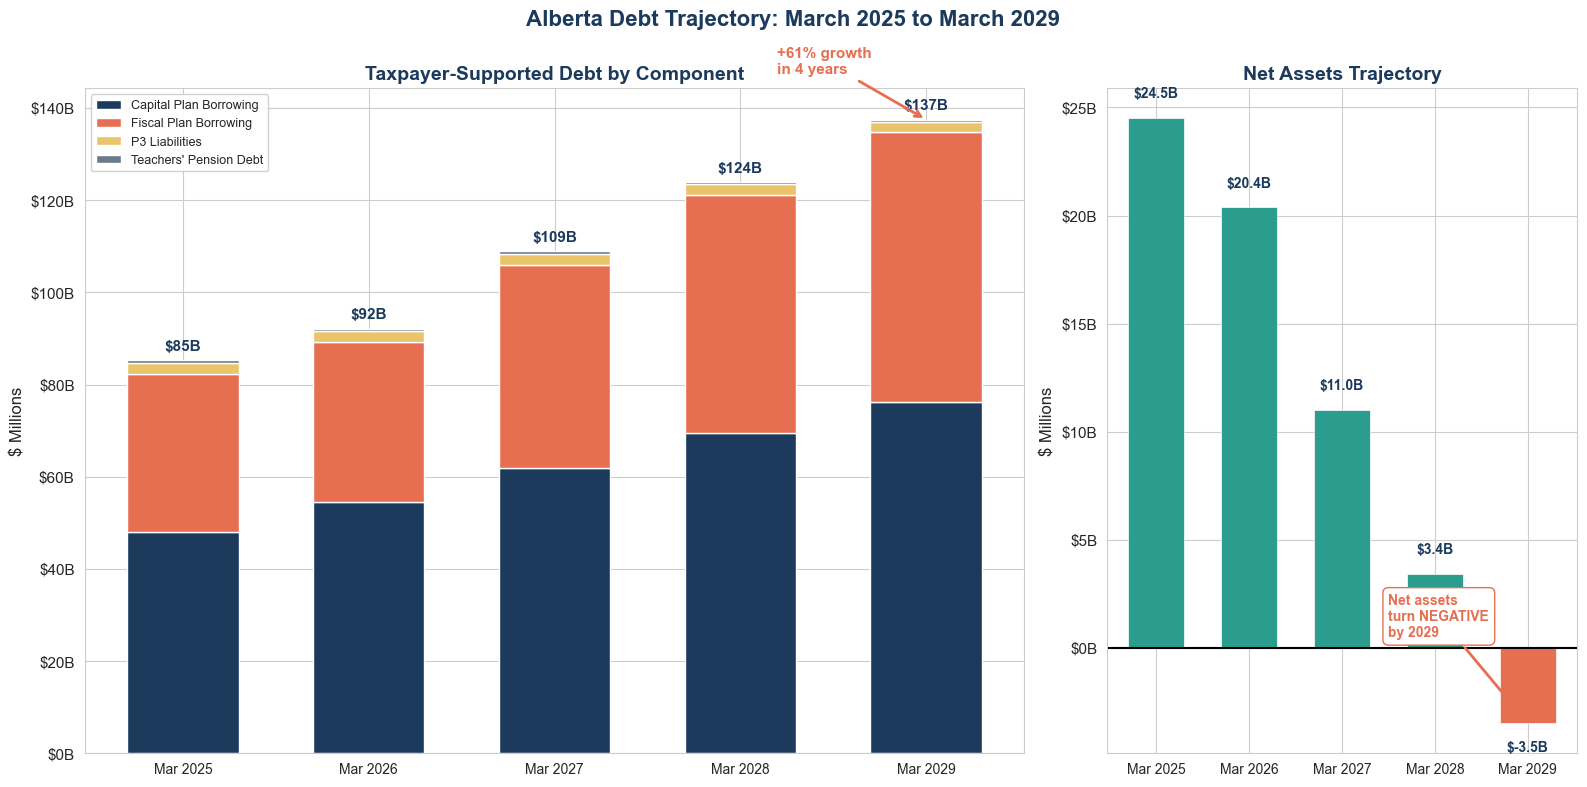

Saved: plots/debt_trajectory.png


In [3]:
# Extract debt components from financial position data
debt_items = fin_position[fin_position['Section'] == 'Liabilities']
year_cols = [c for c in fin_position.columns if 'March' in c or '2025' in c or '2026' in c or '2027' in c or '2028' in c or '2029' in c]
# Actual column names from the CSV
year_cols = [c for c in fin_position.columns if c not in ['Section', 'Item']]
print('Year columns:', year_cols)

def get_value(section, item_substr):
    """Extract a row's values across all year columns."""
    mask = (fin_position['Section'] == section) & (fin_position['Item'].str.contains(item_substr, case=False, na=False))
    row = fin_position[mask]
    if row.empty:
        return [0] * len(year_cols)
    return [float(str(row.iloc[0][c]).replace(',', '')) for c in year_cols]

capital_borrowing = get_value('Liabilities', 'Direct borrowing for the Capital Plan')
fiscal_borrowing = get_value('Liabilities', 'Direct borrowing for the Fiscal Plan')
p3s = get_value('Liabilities', 'P3s')
teachers_pension = get_value('Liabilities', 'Teachers Pension')
total_debt = get_value('Liabilities', 'Total taxpayer-supported debt')
net_assets = get_value('Net Position', 'Net assets')

debt_years = ['Mar 2025', 'Mar 2026', 'Mar 2027', 'Mar 2028', 'Mar 2029']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={'width_ratios': [2, 1]})

# Left: Stacked bar of debt components
x = np.arange(len(debt_years))
width = 0.6

b1 = ax1.bar(x, capital_borrowing, width, label='Capital Plan Borrowing', color=DARK_BLUE)
b2 = ax1.bar(x, fiscal_borrowing, width, bottom=capital_borrowing,
             label='Fiscal Plan Borrowing', color=CORAL)
b3_bottom = [c + f for c, f in zip(capital_borrowing, fiscal_borrowing)]
b3 = ax1.bar(x, p3s, width, bottom=b3_bottom, label='P3 Liabilities', color=AMBER)
b4_bottom = [b + p for b, p in zip(b3_bottom, p3s)]
b4 = ax1.bar(x, teachers_pension, width, bottom=b4_bottom,
             label="Teachers' Pension Debt", color=SLATE)

# Annotate total debt
for i, (xi, td) in enumerate(zip(x, total_debt)):
    ax1.text(xi, td + 1500, f'${td/1000:.0f}B',
             ha='center', va='bottom', fontweight='bold', fontsize=11, color=DARK_BLUE)

ax1.set_xticks(x)
ax1.set_xticklabels(debt_years, fontsize=10)
ax1.set_ylabel('$ Millions', fontsize=12)
ax1.set_title('Taxpayer-Supported Debt by Component', fontsize=14, fontweight='bold', color=DARK_BLUE)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}B'))
ax1.legend(loc='upper left', fontsize=9, framealpha=0.9)

# Growth annotation
growth_pct = (total_debt[-1] - total_debt[0]) / total_debt[0] * 100
ax1.annotate(f'+{growth_pct:.0f}% growth\nin 4 years',
             xy=(4, total_debt[-1]), xytext=(3.2, total_debt[-1] + 10000),
             fontsize=11, fontweight='bold', color=CORAL,
             arrowprops=dict(arrowstyle='->', color=CORAL, lw=2))

# Right: Net assets trajectory
net_colors = [TEAL if v >= 0 else CORAL for v in net_assets]
bars2 = ax2.bar(x, net_assets, width, color=net_colors, edgecolor='white', linewidth=0.5)
ax2.axhline(y=0, color='black', linewidth=1.5)

for i, (xi, na) in enumerate(zip(x, net_assets)):
    offset = 800 if na >= 0 else -800
    va = 'bottom' if na >= 0 else 'top'
    ax2.text(xi, na + offset, f'${na/1000:.1f}B',
             ha='center', va=va, fontweight='bold', fontsize=10,
             color=DARK_BLUE)

ax2.set_xticks(x)
ax2.set_xticklabels(debt_years, fontsize=10)
ax2.set_ylabel('$ Millions', fontsize=12)
ax2.set_title('Net Assets Trajectory', fontsize=14, fontweight='bold', color=DARK_BLUE)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}B'))

# Annotate the crossover to negative
ax2.annotate('Net assets\nturn NEGATIVE\nby 2029',
             xy=(4, net_assets[-1]), xytext=(2.5, net_assets[-1] + 4000),
             fontsize=10, fontweight='bold', color=CORAL,
             arrowprops=dict(arrowstyle='->', color=CORAL, lw=2),
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=CORAL))

fig.suptitle('Alberta Debt Trajectory: March 2025 to March 2029',
             fontsize=16, fontweight='bold', color=DARK_BLUE, y=0.98)
fig.subplots_adjust(top=0.92)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'debt_trajectory.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: plots/debt_trajectory.png')

## Revenue Dependency Risk

Side-by-side donut charts comparing revenue composition in the surplus year (2024-25) vs. the worst deficit year (2026-27), highlighting shrinking resource revenue.

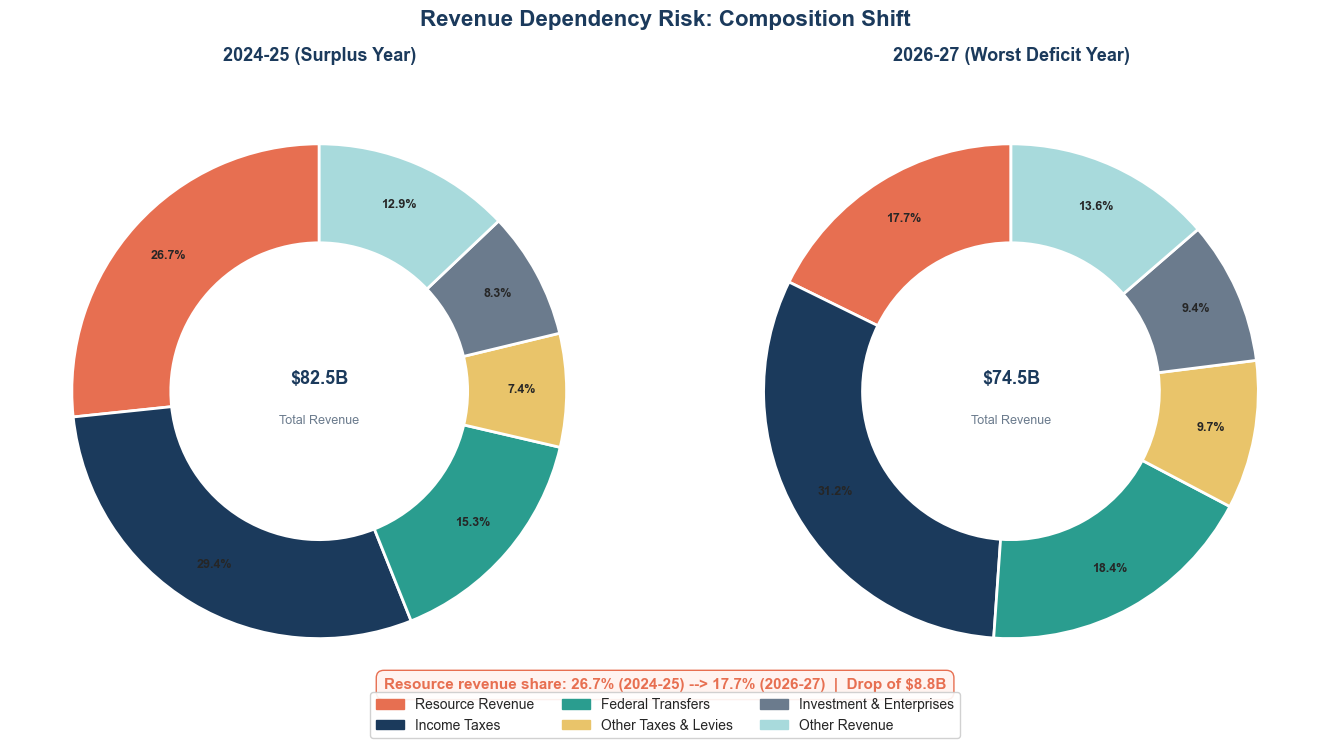

Saved: plots/revenue_dependency_comparison.png


In [4]:
# Build revenue categories for donut charts
rev_df = revenue.copy()

# Group into meaningful categories
def categorize_revenue(row):
    item = row['Item']
    if 'itumen' in item or 'non-renewable' in item.lower():
        return 'Resource Revenue'
    elif 'income tax' in item.lower():
        return 'Income Taxes'
    elif 'tax' in item.lower() or 'levy' in item.lower():
        return 'Other Taxes & Levies'
    elif 'transfer' in item.lower() or 'canada' in item.lower():
        return 'Federal Transfers'
    elif 'investment' in item.lower() or 'enterprise' in item.lower():
        return 'Investment & Enterprises'
    else:
        return 'Other Revenue'

rev_df['Category'] = rev_df.apply(categorize_revenue, axis=1)

# Aggregate for the two comparison years
yr_2024 = rev_df.groupby('Category')['2024-25_Actual'].sum()
yr_2026 = rev_df.groupby('Category')['2026-27_Estimate'].sum()

# Consistent order
cat_order = ['Resource Revenue', 'Income Taxes', 'Federal Transfers',
             'Other Taxes & Levies', 'Investment & Enterprises', 'Other Revenue']
yr_2024 = yr_2024.reindex(cat_order)
yr_2026 = yr_2026.reindex(cat_order)

cat_colors = [CORAL, DARK_BLUE, TEAL, AMBER, SLATE, '#A8DADC']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

def make_donut(ax, data, title, total_label):
    wedges, texts, autotexts = ax.pie(
        data.values, labels=None, autopct='%1.1f%%',
        colors=cat_colors, startangle=90, pctdistance=0.82,
        wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2)
    )
    for t in autotexts:
        t.set_fontsize(9)
        t.set_fontweight('bold')
    # Center text
    ax.text(0, 0.05, total_label, ha='center', va='center',
            fontsize=13, fontweight='bold', color=DARK_BLUE)
    ax.text(0, -0.12, 'Total Revenue', ha='center', va='center',
            fontsize=9, color=SLATE)
    ax.set_title(title, fontsize=13, fontweight='bold', color=DARK_BLUE, pad=15)

make_donut(ax1, yr_2024, '2024-25 (Surplus Year)', f'${yr_2024.sum()/1000:.1f}B')
make_donut(ax2, yr_2026, '2026-27 (Worst Deficit Year)', f'${yr_2026.sum()/1000:.1f}B')

# Highlight resource revenue change
res_2024_pct = yr_2024['Resource Revenue'] / yr_2024.sum() * 100
res_2026_pct = yr_2026['Resource Revenue'] / yr_2026.sum() * 100

fig.text(0.5, 0.04,
         f'Resource revenue share: {res_2024_pct:.1f}% (2024-25) --> {res_2026_pct:.1f}% (2026-27)  |  '
         f'Drop of ${(yr_2024["Resource Revenue"] - yr_2026["Resource Revenue"])/1000:.1f}B',
         ha='center', fontsize=11, fontweight='bold', color=CORAL,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF3F0', edgecolor=CORAL))

# Shared legend below the donuts
legend_patches = [mpatches.Patch(color=c, label=l) for c, l in zip(cat_colors, cat_order)]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=10, framealpha=0.9, bbox_to_anchor=(0.5, -0.04))

fig.suptitle('Revenue Dependency Risk: Composition Shift',
             fontsize=16, fontweight='bold', color=DARK_BLUE, y=1.01)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'revenue_dependency_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: plots/revenue_dependency_comparison.png')

## The Scissors Effect: Revenue vs Expense Divergence

The defining chart of Alberta's fiscal challenge: revenue falling while expenses rise, creating a widening gap that drives structural deficits.

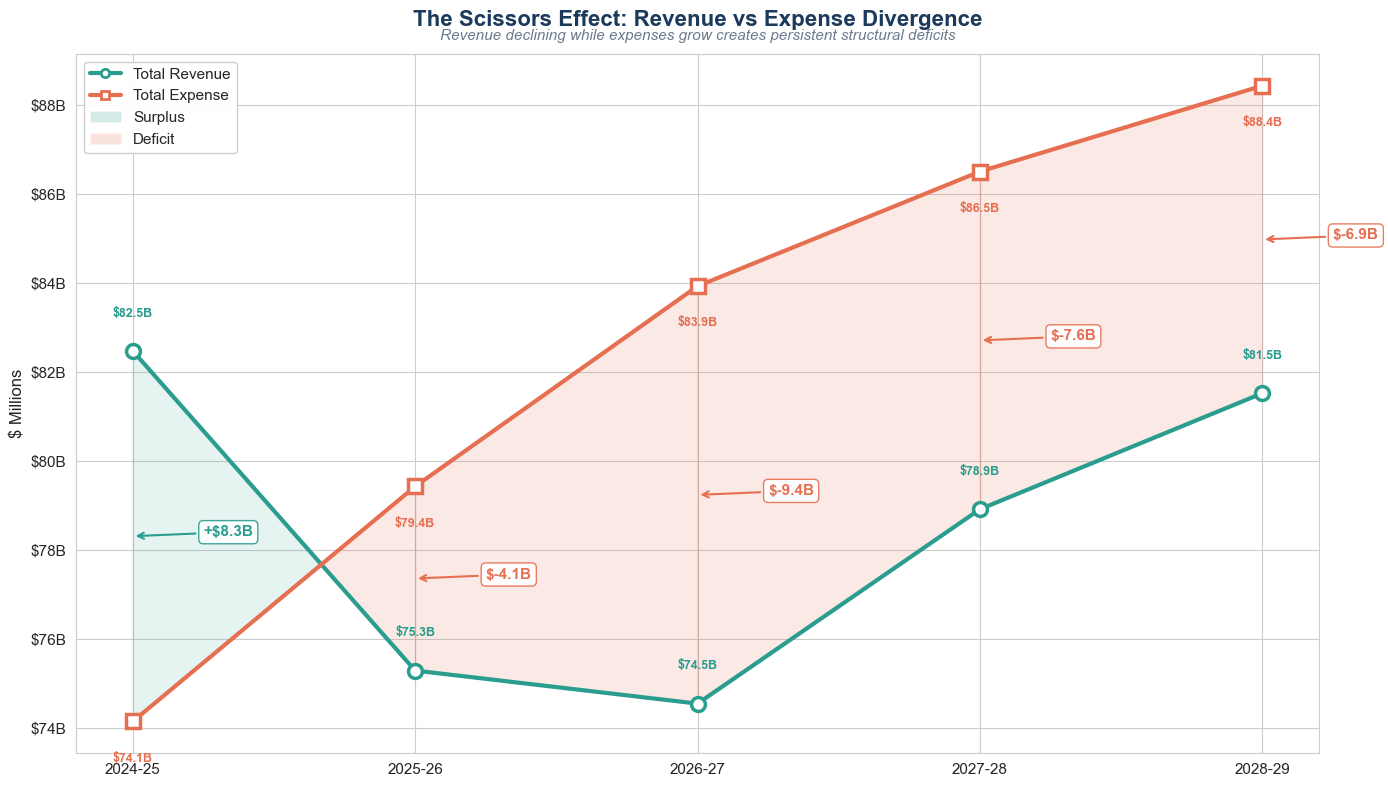

Saved: plots/scissors_effect.png


In [5]:
# Scissors effect chart
fig, ax = plt.subplots(figsize=(14, 8))

rev_vals = summary['Total_Revenue'].values
exp_vals = summary['Total_Expense'].values
x = np.arange(len(years))

# Plot lines
ax.plot(x, rev_vals, color=TEAL, linewidth=3, marker='o', markersize=10,
        markerfacecolor='white', markeredgewidth=2.5, label='Total Revenue', zorder=5)
ax.plot(x, exp_vals, color=CORAL, linewidth=3, marker='s', markersize=10,
        markerfacecolor='white', markeredgewidth=2.5, label='Total Expense', zorder=5)

# Fill between - green where surplus, red where deficit
for i in range(len(x) - 1):
    xi = [x[i], x[i+1]]
    ri = [rev_vals[i], rev_vals[i+1]]
    ei = [exp_vals[i], exp_vals[i+1]]
    if rev_vals[i] >= exp_vals[i] and rev_vals[i+1] >= exp_vals[i+1]:
        ax.fill_between(xi, ri, ei, color=TEAL, alpha=0.12)
    elif rev_vals[i] <= exp_vals[i] and rev_vals[i+1] <= exp_vals[i+1]:
        ax.fill_between(xi, ri, ei, color=CORAL, alpha=0.15)
    else:
        # Crossover year - split
        # Find intersection point
        r0, r1 = rev_vals[i], rev_vals[i+1]
        e0, e1 = exp_vals[i], exp_vals[i+1]
        t = (r0 - e0) / ((r0 - e0) - (r1 - e1))
        x_cross = x[i] + t
        y_cross = r0 + t * (r1 - r0)
        # Fill surplus portion
        ax.fill_between([x[i], x_cross], 
                       [r0, y_cross], [e0, y_cross],
                       color=TEAL, alpha=0.12)
        # Fill deficit portion
        ax.fill_between([x_cross, x[i+1]],
                       [y_cross, r1], [y_cross, e1],
                       color=CORAL, alpha=0.15)

# Annotate each year's gap
for i, yr in enumerate(years):
    gap = rev_vals[i] - exp_vals[i]
    mid_y = (rev_vals[i] + exp_vals[i]) / 2
    sign = '+' if gap > 0 else ''
    color = TEAL if gap > 0 else CORAL
    ax.annotate(f'{sign}${gap/1000:.1f}B',
                xy=(x[i], mid_y), xytext=(x[i] + 0.25, mid_y),
                fontsize=11, fontweight='bold', color=color,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                         edgecolor=color, alpha=0.9),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

# Value labels on lines
for i in range(len(years)):
    ax.text(x[i], rev_vals[i] + 700, f'${rev_vals[i]/1000:.1f}B',
            ha='center', va='bottom', fontsize=9, fontweight='bold', color=TEAL)
    ax.text(x[i], exp_vals[i] - 700, f'${exp_vals[i]/1000:.1f}B',
            ha='center', va='top', fontsize=9, fontweight='bold', color=CORAL)

ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=11)
ax.set_ylabel('$ Millions', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}B'))

# Legend with custom patches
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=TEAL, linewidth=3, marker='o', markerfacecolor='white',
           markeredgewidth=2, label='Total Revenue'),
    Line2D([0], [0], color=CORAL, linewidth=3, marker='s', markerfacecolor='white',
           markeredgewidth=2, label='Total Expense'),
    mpatches.Patch(facecolor=TEAL, alpha=0.2, label='Surplus'),
    mpatches.Patch(facecolor=CORAL, alpha=0.2, label='Deficit'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.95)

ax.set_title('The Scissors Effect: Revenue vs Expense Divergence',
             fontsize=16, fontweight='bold', color=DARK_BLUE, pad=20)

# Subtitle
ax.text(0.5, 1.02, 'Revenue declining while expenses grow creates persistent structural deficits',
        transform=ax.transAxes, ha='center', fontsize=11, color=SLATE, style='italic')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'scissors_effect.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: plots/scissors_effect.png')

## Summary of Core Visualizations

These four charts tell a cohesive fiscal story:

1. **Fiscal Balance Waterfall** -- Alberta's $8.3B surplus in 2024-25 evaporates through a combination of declining resource revenue and rising expenditures, producing deficits of $4.1B to $9.4B across the forecast horizon.

2. **Debt Trajectory** -- Taxpayer-supported debt grows from $85B to $137B (+61%) in just four years. Fiscal Plan borrowing (deficit financing) becomes the fastest-growing component. Net assets turn negative by March 2029, meaning Alberta's liabilities exceed its assets for the first time.

3. **Revenue Dependency Risk** -- The donut chart comparison reveals how resource revenue shrinks from ~27% to ~18% of total revenue between the surplus year and the worst deficit year, a $8.8B drop that tax growth cannot offset.

4. **The Scissors Effect** -- The signature chart of this analysis. Revenue and expense lines diverge like opening scissors, with the deficit gap widening from zero to nearly $10B. This structural divergence is the central fiscal challenge facing Alberta.